### Load dataset

In [1]:
import os
import sys
import math
from tqdm import tqdm
from pathlib import Path
from typing import Any, overload
from collections import defaultdict

import torch
import wandb
import numpy as np
from torch import nn, Tensor
import matplotlib.pyplot as plt
import torch.nn.functional as F
from torch.optim import Optimizer, AdamW
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader
from torch.optim.lr_scheduler import LRScheduler, LambdaLR

from src.models import MAE_ViT
from src import configs as cfg
from src import models, plotting
from src.utils import setup_seed
from src import dataset, metrics, plotting

/root/repos/raidium_challenge/.venv/lib/python3.13/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [2]:
path = "pretrained_vit_epoch_750.pt"

In [3]:
chkpt = torch.load(path, weights_only=False)
train_cfg = chkpt["train_cfg"]
if "mask_rec_loss_weight" in train_cfg:
    del train_cfg["mask_rec_loss_weight"]
train_cfg = cfg.TrainingConfig(**train_cfg)
model_cfg = cfg.ModelConfig(**chkpt["model_cfg"])
model = models.mk_model_from_cfg(model_cfg)
model.load_state_dict(chkpt["model"])

<All keys matched successfully>

In [ ]:
model_cfg.arch

In [4]:
loaders = dataset.mk_semi_supervised_data_loaders(train_cfg)

with training transforms


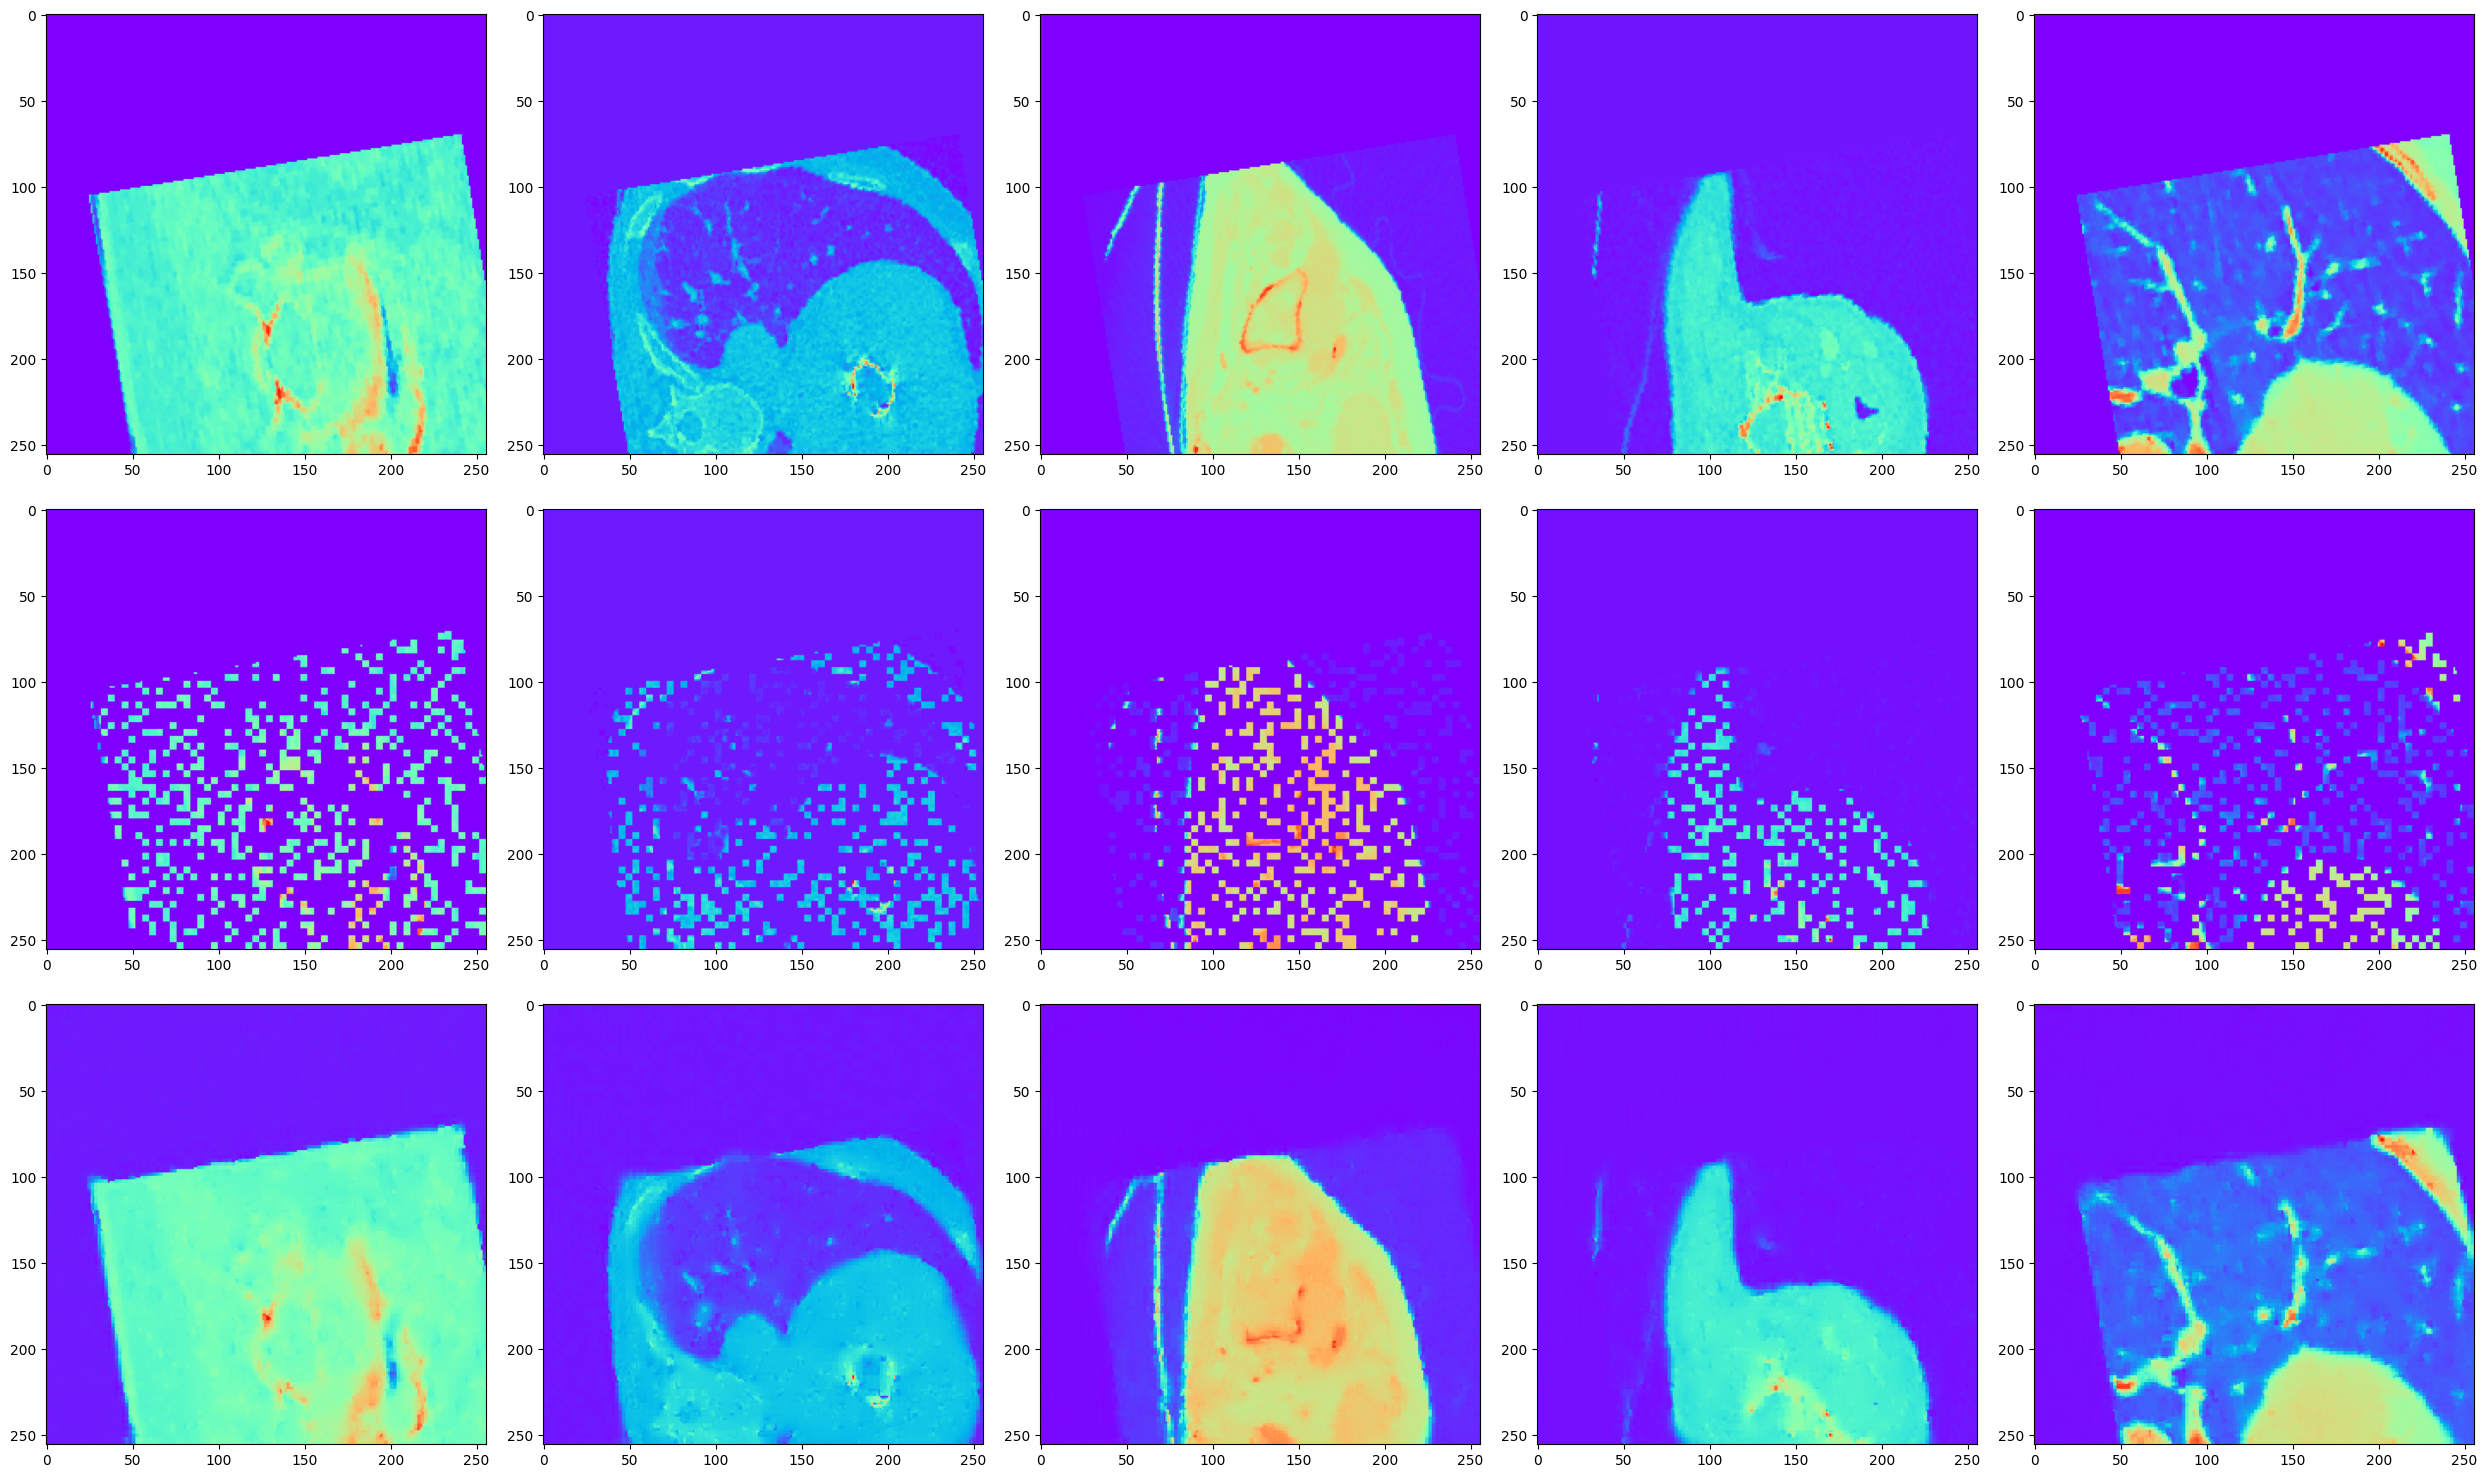

without transforms


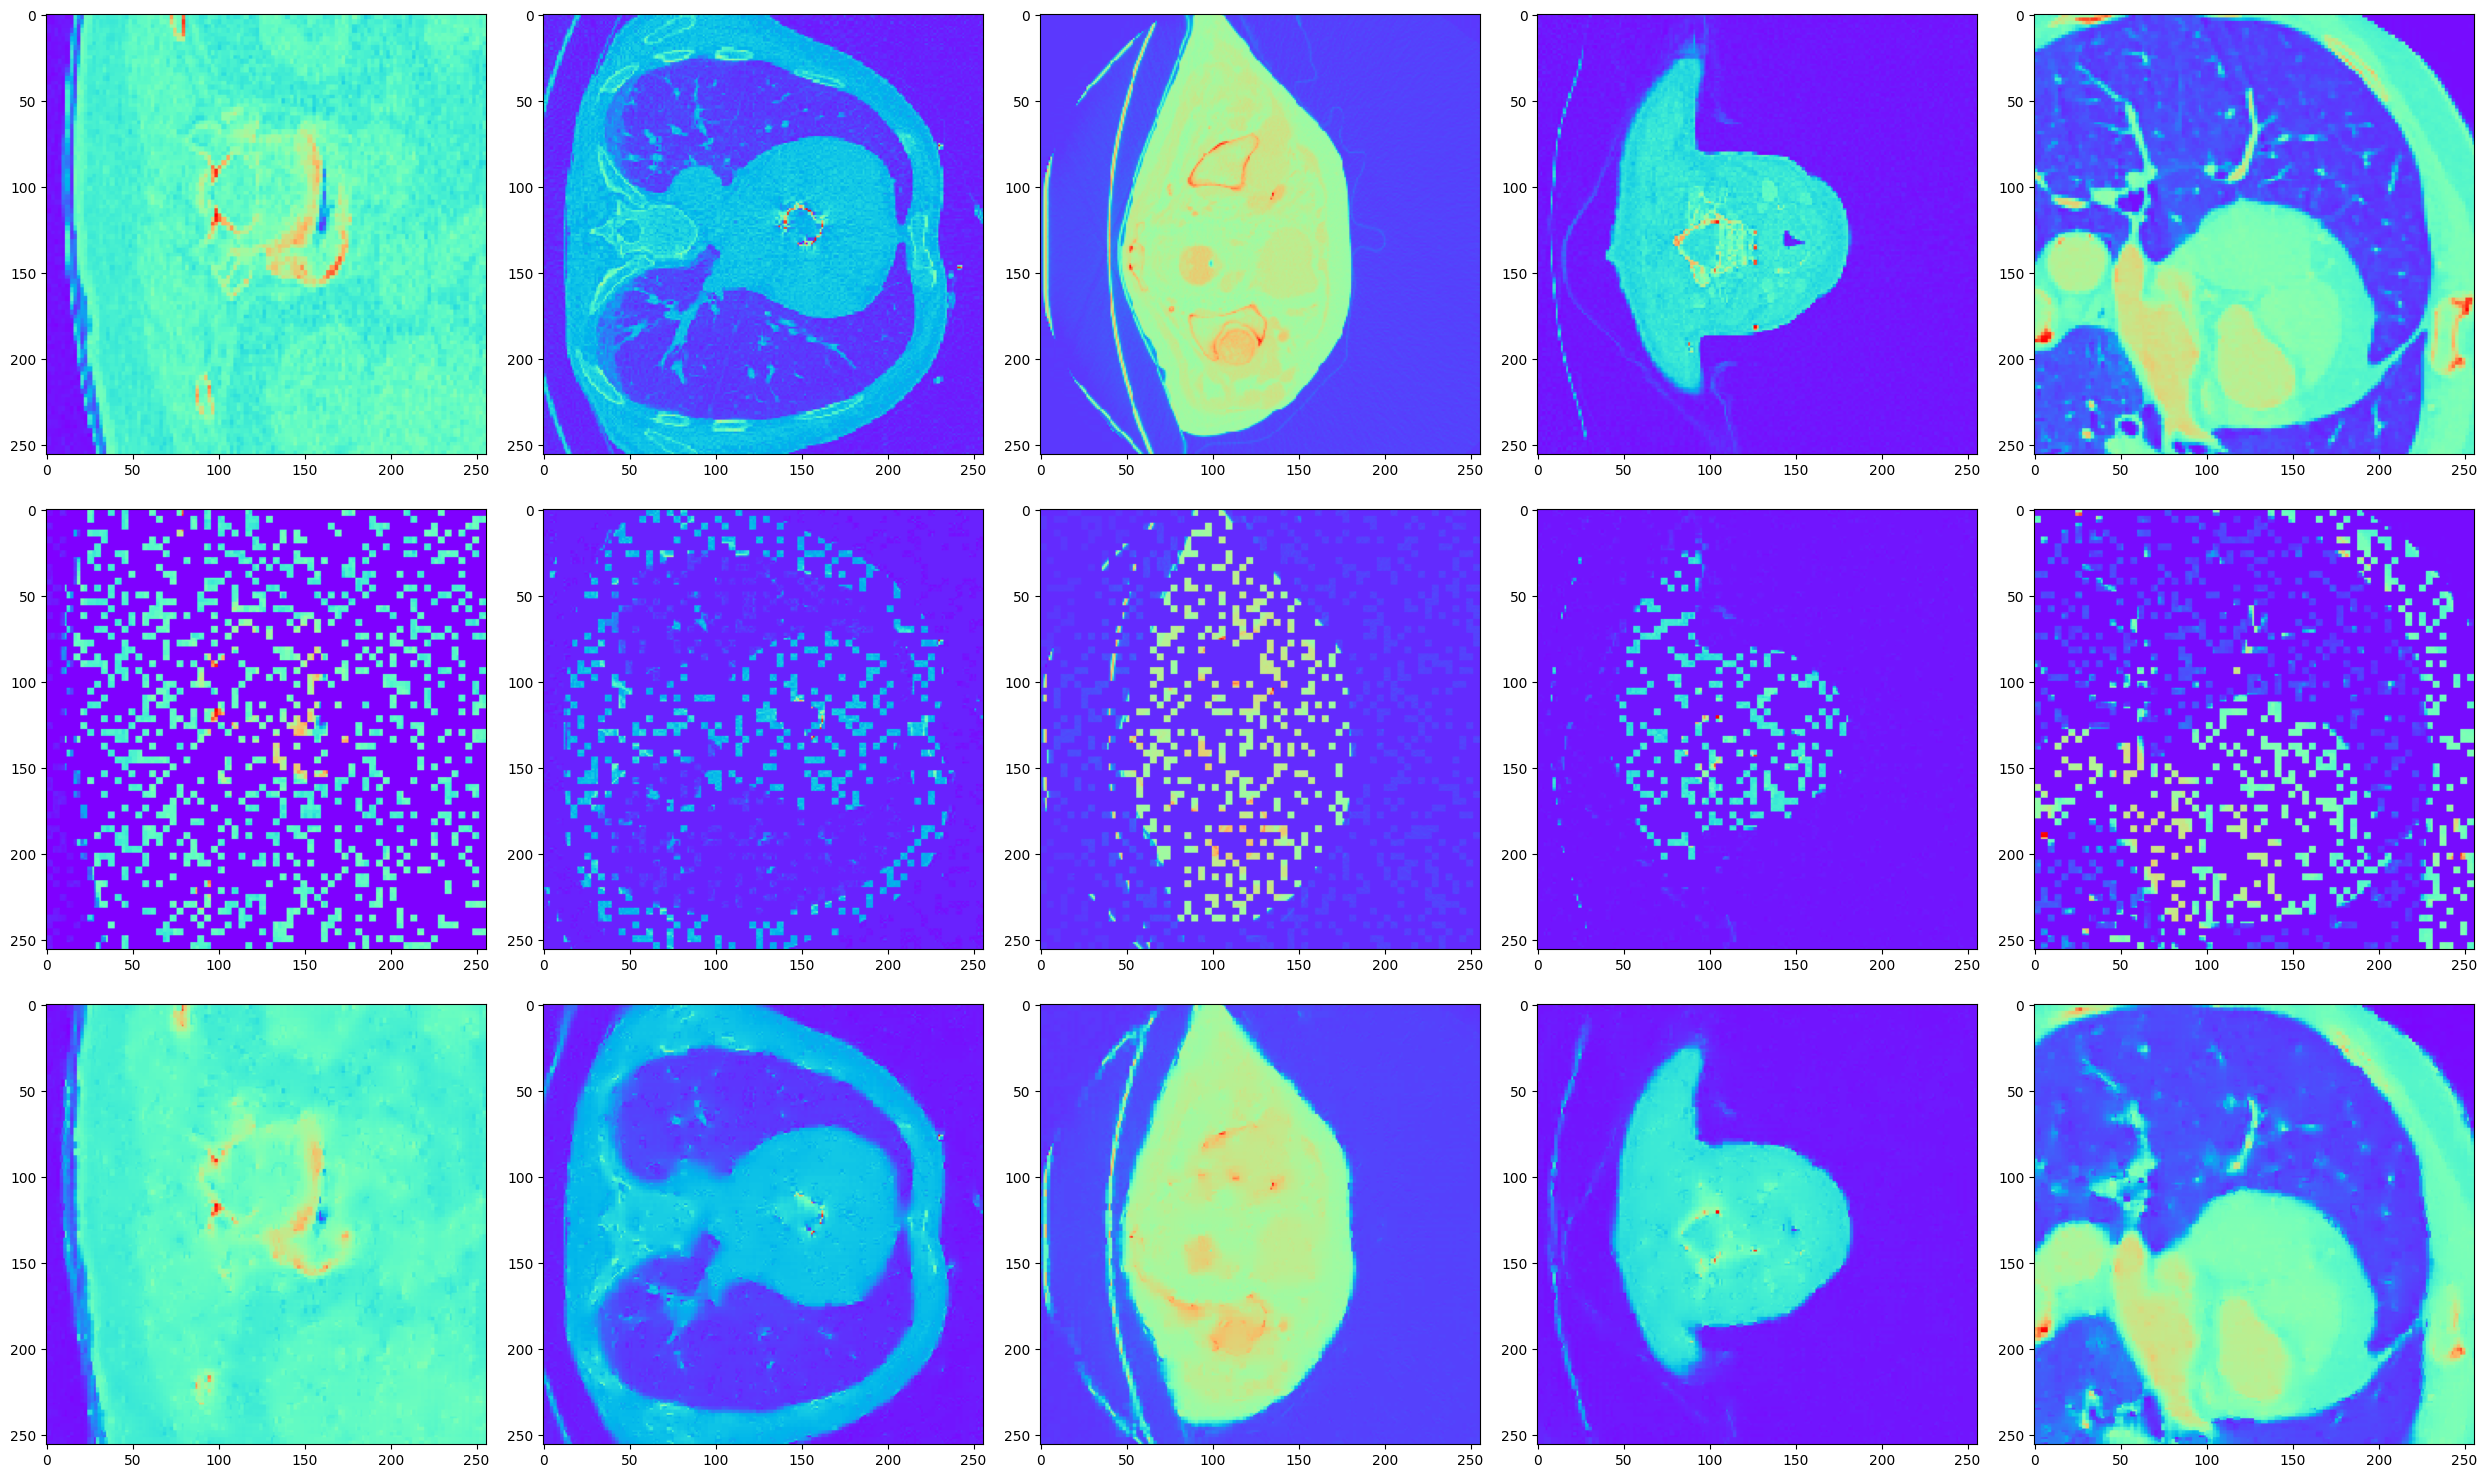

In [6]:
x, y_true = next(iter(loaders["train"]))
with torch.no_grad():
    print("with training transforms")
    plotting.plt_recon_imgs_matplotlib(model, {"x": x, "y_true": y_true}, train_cfg.transform)
    print("without transforms")
    plotting.plt_recon_imgs_matplotlib(model, {"x": x, "y_true": y_true})